### 1. 数据集准备
* 定义数据预处理，包括缩放分辨率和训练时随机翻转
* 注意修改 ImageFolder 中的 root 位置（Kaggle 中无需修改）

In [3]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
import os
os.chdir(r"I:\STUDY\python\project\machine-learning\2.0\2.3")
print(os.listdir(os.getcwd()))
print(os.getcwd())
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
train_data = ImageFolder(root=r'./2-MedImage-TrainSet', transform=train_transform)
test_data = ImageFolder(root=r'./2-MedImage-TestSet', transform=test_transform)

print('训练样本数量:', train_data.__len__())
print('测试样本数量:', test_data.__len__())
print('类别列表:', train_data.classes)


['2-MedImage-TestSet', '2-MedImage-TestSet.zip', '2-MedImage-TrainSet', '2-MedImage-TrainSet.zip', 'ml-course2.ipynb', 'requirements.txt', 'testtorch.py', '使用方法.pdf']
I:\STUDY\python\project\machine-learning\2.0\2.3
训练样本数量: 1639
测试样本数量: 250
类别列表: ['disease', 'normal']


### 2. 定义模型：
* 示例模型采用efficientnet_b0，也可以尝试其他不同的模型，[参考链接](https://docs.pytorch.org/vision/stable/models.html) **也可以自定义模型进行训练**
* 这里不使用预训练模型，可以自行修改use_pretrained 为 True
* 为了适应2分类任务，模型的最后一个全连接层输出维度需要改成 2

In [4]:
import torch
import torch.nn as nn
from torchvision import models

use_pretrained = None
num_classes = len(train_data.classes)
print('num_classes:', num_classes)
model = models.efficientnet_b0(weights=use_pretrained)
# 替换最后一个全连接层
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, num_classes)

num_classes: 2


### 3. 进行训练
* 可以自行修改训练配置参数

In [5]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch.optim as optim
import copy
import time

# 训练参数（按需调整）
batch_size = 32
num_workers = 0
num_epochs = 10
learning_rate = 1e-4
weight_decay = 0
save_path = 'best_model.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cuda')
print('Device:', device)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(test_data,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

# 打印/进度条控制开关
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

criterion = nn.CrossEntropyLoss()
train_losses = []
val_losses = []
best_acc = 0.5
best_model_wts = copy.deepcopy(model.state_dict())
torch.cuda.empty_cache()
model.to(device)

for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()

    # 训练阶段
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    lr = optimizer.param_groups[0]['lr']
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} | LR {lr:.2e}')
    for inputs, labels in pbar:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        loss.backward()
        optimizer.step()

        bs = inputs.size(0)
        running_loss += loss.item() * bs
        running_corrects += torch.sum(preds == labels).item()
        total += bs
        pbar.set_postfix(loss=f'{running_loss/total:.4f}', acc=f'{running_corrects/total:.4f}')

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    train_losses.append(epoch_loss)

    # 验证阶段
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Val', leave=False):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            bs = inputs.size(0)
            val_loss += loss.item() * bs
            val_corrects += torch.sum(preds == labels).item()
            val_total += bs

    val_loss = val_loss / val_total if val_total > 0 else 0.0
    val_acc = val_corrects / val_total if val_total > 0 else 0.0
    print(f'Val   Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
    val_losses.append(val_loss)

    # scheduler.step(val_loss)

    # 保存最佳模型
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'best_acc': best_acc,
            'optimizer_state_dict': optimizer.state_dict()
        }, save_path)
        print(f'Best model saved (acc={best_acc:.4f}) -> {save_path}')
# import torch
# print(torch.__version__)
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name())


Device: cuda


Epoch 1/10 | LR 1.00e-04: 100%|██████████| 52/52 [00:29<00:00,  1.78it/s, acc=0.6345, loss=0.6550]


Val   Loss: 0.6801 Acc: 0.6000
Best model saved (acc=0.6000) -> best_model.pth


Epoch 2/10 | LR 1.00e-04: 100%|██████████| 52/52 [00:28<00:00,  1.85it/s, acc=0.7230, loss=0.5624]


Val   Loss: 0.6984 Acc: 0.6320
Best model saved (acc=0.6320) -> best_model.pth


...

Val   Loss: 0.4896 Acc: 0.8200


Epoch 9/10 | LR 1.00e-04: 100%|██████████| 52/52 [00:27<00:00,  1.88it/s, acc=0.9164, loss=0.2157]


Val   Loss: 0.3614 Acc: 0.8400


Epoch 10/10 | LR 1.00e-04: 100%|██████████| 52/52 [00:27<00:00,  1.86it/s, acc=0.9384, loss=0.1634]
                                                  

Val   Loss: 0.3012 Acc: 0.8960
Best model saved (acc=0.8960) -> best_model.pth


### 4. 绘制训练和验证Loss曲线

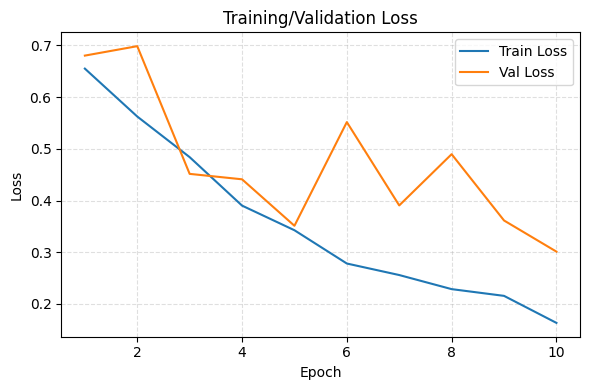

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=300)
plt.show()

### 5. 进行测试，并且计算评价指标

C:\Users\18030\AppData\Local\Temp\ipykernel_22132\34854833.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location=device)


Loaded checkpoint from best_model.pth (best_acc=0.896)


Test Loss: 0.3012  Acc: 0.8960  (224/250)
Confusion matrix (rows=true, cols=pred):
[[ 94   6]
 [ 20 130]]
              precision    recall  f1-score   support

     disease     0.8246    0.9400    0.8785       100
      normal     0.9559    0.8667    0.9091       150

    accuracy                         0.8960       250
   macro avg     0.8902    0.9033    0.8938       250
weighted avg     0.9034    0.8960    0.8969       250

AUC: 0.9615


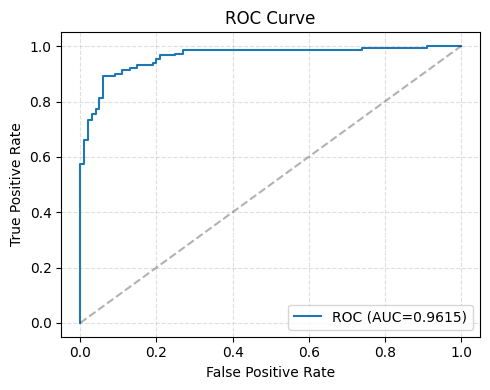

In [10]:

import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
print(f"Loaded checkpoint from {save_path} (best_acc={checkpoint.get('best_acc', None)})")

criterion = nn.CrossEntropyLoss()

test_loss = 0.0
test_correct = 0
test_total = 0
all_labels = []
all_preds = []
all_probs = []   # 正类(标签=1)概率

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc='Test', leave=False):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)      # [B,2]
        pos_prob = probs[:, 1]                     # 正类概率
        _, preds = torch.max(outputs, 1)

        bs = inputs.size(0)
        test_loss += loss.item() * bs
        test_correct += torch.sum(preds == labels).item()
        test_total += bs

        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(pos_prob.cpu().tolist())

test_loss = test_loss / max(test_total, 1)
test_acc = test_correct / max(test_total, 1)
print(f"Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}  ({test_correct}/{test_total})")

# 混淆矩阵与分类报告
cm = confusion_matrix(all_labels, all_preds)
print('Confusion matrix (rows=true, cols=pred):')
print(cm)
target_names = train_data.classes if len(train_data.classes) == 2 else ['0','1']
print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

# ROC & AUC（二分类）
y_true = np.array(all_labels)
y_score = np.array(all_probs)
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()